# Análisis de partido — Huracán vs Banfield
**Competición:** Liga Argentina — Clausura 2026  
**Fecha:** 17/05/2026  
**Resultado:** Huracán 1 - 0 Banfield  
**Fuente de datos:** FBref  
**Autor:** Andrés  

---

## Estructura del notebook

1. Setup e importaciones  
2. Carga del dataset  
3. Limpieza  
4. EDA — Análisis exploratorio  

> Los datos corresponden a las estadísticas individuales de los jugadores del partido.  
> La limpieza se realiza sobre `df_raw` y el análisis sobre `df_clean`.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Configuración de gráficos
sns.set_theme(style='whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

# Supresión de warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Configuración de visualización del DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuración del partido
EQUIPO_LOCAL     = 'Huracán'
EQUIPO_VISITANTE = 'Banfield'
RESULTADO        = '1 - 0'
FECHA            = '17/05/2026'
COMPETICION      = 'Liga Argentina — Clausura 2026'

os.makedirs('../outputs', exist_ok=True)

print('✅ Configuración lista')

✅ Configuración lista


## 2. Carga del dataset

In [2]:
# ── Configuración ──────────────────────────────────────────
DATA_PATH = '../data/raw/huracan_banfield_raw.csv'
SEPARATOR = ','
ENCODING  = 'utf-8'
# ───────────────────────────────────────────────────────────

df_raw = pd.read_csv(DATA_PATH, sep=SEPARATOR, encoding=ENCODING)
print(f'✅ Dataset cargado — Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')
print(f'   Fuente: FBref | Partido: {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} | Fecha: {FECHA}')

✅ Dataset cargado — Filas: 32 | Columnas: 21
   Fuente: FBref | Partido: Huracán vs Banfield | Fecha: 17/05/2026


## 3. Limpieza

### 3.1 Diagnóstico inicial

Primer vistazo al dataset crudo para identificar problemas de estructura, tipos y calidad de datos.

In [3]:
# ─── Primeras y últimas filas ──────────────────────────────────────────────
print('\n--- Primeras 5 filas ---')
display(df_raw.head())

print('\n--- Últimas 5 filas ---')
display(df_raw.tail())

# ─── Dimensiones ───────────────────────────────────────────────────────────
print(f'\nFilas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')

# ─── Tipos de datos ────────────────────────────────────────────────────────
print('\n--- Info general ---')
df_raw.info()

# ─── Valores nulos por columna ─────────────────────────────────────────────
print('\n--- Nulos por columna ---')
if df_raw.isnull().sum().sum() == 0:
    print('✅ Sin valores nulos')
else:
    nulos = pd.DataFrame({
        'Nulos': df_raw.isnull().sum(),
        'Porcentaje': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
    })
    display(nulos[nulos['Nulos'] > 0])

# ─── Duplicados ────────────────────────────────────────────────────────────
print(f'\nFilas duplicadas: {df_raw.duplicated().sum()}')

# ─── Estadísticas descriptivas ─────────────────────────────────────────────
print('\n--- Estadísticas descriptivas ---')
display(df_raw.describe())


--- Primeras 5 filas ---


,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG
0,Bruno Sepúlveda,9,AR,FW,33-310,71,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0
1,Federico Anselmo,30,AR,FW,32-098,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,Tiziano Perrotta,17,AR,FW,19-241,90,0,0,0,0,1,0,0,0,0,0,3,0,2,0,0
3,Lautaro Gómez,10,AR,LM,22-350,71,0,0,0,0,1,1,0,0,1,1,0,2,0,1,0
4,Federico Medina,18,AR,MF,22-158,19,0,0,0,0,0,0,0,0,1,1,0,2,0,0,0



--- Últimas 5 filas ---


,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG
27,Leandro Lescano,19,AR,MF,23-143,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
28,Máximo Palazzo,35,AR,CB,21-048,90,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0
29,Hugo Nervo,21,AR,CB,35-199,90,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
30,Lucas Blondel,2,CH,RB,29-313,90,0,0,0,0,2,1,0,0,2,2,0,2,2,1,0
31,Hernán Galíndez,1,ECU,GK,39-116,90,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Filas: 32 | Columnas: 21

--- Info general ---
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Player  32 non-null     str  
 1   #       32 non-null     int64
 2   Nation  32 non-null     str  
 3   Pos     32 non-null     str  
 4   Age     32 non-null     str  
 5   Min     32 non-null     int64
 6   Gls     32 non-null     int64
 7   Ast     32 non-null     int64
 8   PK      32 non-null     int64
 9   PKatt   32 non-null     int64
 10  Sh      32 non-null     int64
 11  SoT     32 non-null     int64
 12  CrdY    32 non-null     int64
 13  CrdR    32 non-null     int64
 14  Fls     32 non-null     int64
 15  Fld     32 non-null     int64
 16  Off     32 non-null     int64
 17  Crs     32 non-null     int64
 18  TklW    32 non-null     int64
 19  Int     32 non-null     int64
 20  OG      32 non-null     int64
dtypes: int64(17), str(4)
memory usage: 5.4 KB

--- Nul

,#,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00
mean,16.50,61.88,0.03,0.03,0.00,0.00,0.81,0.38,0.12,0.00,0.72,0.69,0.16,0.88,0.69,0.62,0.00
std,10.93,33.53,0.18,0.18,0.00,0.00,1.38,0.71,0.34,0.00,1.02,0.86,0.63,1.84,1.03,0.91,0.00
min,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.75,32.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,17.00,79.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,24.00,90.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00
max,40.00,90.00,1.00,1.00,0.00,0.00,6.00,3.00,1.00,0.00,3.00,3.00,3.00,9.00,4.00,4.00,0.00


### 3.2 Separar columna Age

FBref almacena la edad en formato `años-días` (ej: `32-352`).  
La separamos en dos columnas numéricas para poder trabajarlas individualmente.  
**Decisión:** se mantienen ambas columnas — `edad_años` para análisis de distribución, `edad_dias` para comparaciones con precisión exacta.

In [4]:
# Separar Age en años y días
df_raw[['edad_años', 'edad_dias']] = df_raw['Age'].str.split('-', expand=True).astype(int)

# Verificar
print(f"NaN en edad_años: {df_raw['edad_años'].isnull().sum()}")
print(f"NaN en edad_dias: {df_raw['edad_dias'].isnull().sum()}")
display(df_raw[['Age', 'edad_años', 'edad_dias']].head(5))

# Eliminar columna original
df_raw = df_raw.drop(columns=['Age'])
print('✅ Columna Age eliminada')

NaN en edad_años: 0
NaN en edad_dias: 0


,Age,edad_años,edad_dias
0,33-310,33,310
1,32-098,32,98
2,19-241,19,241
3,22-350,22,350
4,22-158,22,158


✅ Columna Age eliminada


### 3.3 Reset de índice

Luego de las modificaciones, reseteamos el índice para garantizar una secuencia limpia.

In [5]:
print(f'Índice antes del reset: {df_raw.index.tolist()[:10]}...')

df_raw = df_raw.reset_index(drop=True)

print(f'Índice después del reset: {df_raw.index.tolist()[:10]}...')
print(f'Filas finales: {df_raw.shape[0]}')

Índice antes del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Índice después del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Filas finales: 32


### 3.4 Reporte de calidad post limpieza

Verificación final antes de exportar el dataset limpio.

In [6]:
print('=' * 50)
print('REPORTE FINAL DE CALIDAD')
print('=' * 50)
print(f'Partido:            {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE}')
print(f'Fecha:              {FECHA}')
print(f'Filas finales:      {df_raw.shape[0]}')
print(f'Columnas:           {df_raw.shape[1]}')
print(f'Duplicados:         {df_raw.duplicated().sum()}')
print(f'Nulos totales:      {df_raw.isnull().sum().sum()}')
print('=' * 50)

REPORTE FINAL DE CALIDAD
Partido:            Huracán vs Banfield
Fecha:              17/05/2026
Filas finales:      32
Columnas:           22
Duplicados:         0
Nulos totales:      0


### 3.5 Exportar dataset limpio

Creamos `df_clean` como copia de `df_raw` ya procesado y lo exportamos a `data/clean/`.

In [7]:
df_clean = df_raw.copy()

nombre_salida = '../data/clean/huracan_banfield_clean.csv'
df_clean.to_csv(nombre_salida, index=False, encoding='utf-8')
print(f'✅ Dataset exportado: {nombre_salida}')
print(f'   Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}')

✅ Dataset exportado: ../data/clean/huracan_banfield_clean.csv
   Filas: 32 | Columnas: 22


## 4. EDA — Análisis exploratorio

### 4.1 Traducción de columnas y posiciones

FBref usa nombres de columnas y abreviaturas de posición en inglés.  
Traducimos al español para facilitar la lectura de los análisis y visualizaciones.

In [8]:
# ── Diccionarios de traducción FBref ─────────────────────────────────────
# Fuente: glosario oficial FBref

COLUMNAS_ES = {
    'Player':  'Jugador',
    '#':       'Camiseta',
    'Pos':     'Posición',
    'Age':     'Edad',
    'Min':     'Minutos',
    'Gls':     'Goles',
    'Ast':     'Asistencias',
    'PK':      'Penales convertidos',
    'PKatt':   'Penales intentados',
    'Sh':      'Tiros totales',
    'SoT':     'Tiros al arco',
    'CrdY':    'Tarjetas amarillas',
    'CrdR':    'Tarjetas rojas',
    'Fls':     'Faltas cometidas',
    'Fld':     'Faltas recibidas',
    'Off':     'Fueras de juego',
    'Crs':     'Centros',
    'TklW':    'Entradas ganadas',
    'Int':     'Intercepciones',
    'OG':      'Goles en contra',
    'PKwon':   'Penales ganados',
    'PKcon':   'Penales concedidos',
}

POSICIONES_ES = {
    'GK':   'Arquero',
    'DF':   'Defensor',
    'MF':   'Mediocampista',
    'FW':   'Delantero',
    'FB':   'Lateral',
    'LB':   'Lateral izquierdo',
    'RB':   'Lateral derecho',
    'CB':   'Defensor central',
    'DM':   'Mediocampista defensivo',
    'CM':   'Mediocampista central',
    'LM':   'Mediocampista izquierdo',
    'RM':   'Mediocampista derecho',
    'WM':   'Mediocampista amplio',
    'LW':   'Extremo izquierdo',
    'RW':   'Extremo derecho',
    'AM':   'Mediocampista ofensivo',
}


def traducir_columnas(df):
    columnas_presentes = {k: v for k, v in COLUMNAS_ES.items() if k in df.columns}
    df = df.rename(columns=columnas_presentes)
    print(f'Columnas traducidas: {len(columnas_presentes)}')
    return df


def traducir_posiciones(df, columna='Posición'):
    if columna not in df.columns:
        print(f"Columna '{columna}' no encontrada")
        return df

    def traducir_pos(valor):
        if pd.isna(valor):
            return valor
        partes = str(valor).split(',')
        traducidas = [POSICIONES_ES.get(p.strip(), p.strip()) for p in partes]
        return ' / '.join(traducidas)

    df[columna] = df[columna].apply(traducir_pos)
    return df


df_clean = traducir_posiciones(df_clean, columna='Pos')
df_clean = traducir_columnas(df_clean)
print('✅ Traducción aplicada')
display(df_clean.head())

Columnas traducidas: 19
✅ Traducción aplicada


,Jugador,Camiseta,Nation,Posición,Minutos,Goles,Asistencias,Penales convertidos,Penales intentados,Tiros totales,Tiros al arco,Tarjetas amarillas,Tarjetas rojas,Faltas cometidas,Faltas recibidas,Fueras de juego,Centros,Entradas ganadas,Intercepciones,Goles en contra,edad_años,edad_dias
0,Bruno Sepúlveda,9,AR,Delantero,71,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,33,310
1,Federico Anselmo,30,AR,Delantero,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32,98
2,Tiziano Perrotta,17,AR,Delantero,90,0,0,0,0,1,0,0,0,0,0,3,0,2,0,0,19,241
3,Lautaro Gómez,10,AR,Mediocampista izquierdo,71,0,0,0,0,1,1,0,0,1,1,0,2,0,1,0,22,350
4,Federico Medina,18,AR,Mediocampista,19,0,0,0,0,0,0,0,0,1,1,0,2,0,0,0,22,158


### 4.2 Diagnóstico post traducción

Verificamos tipos de datos y estructura del dataset ya traducido, antes de comenzar el análisis.

In [9]:
print('--- Tipos de datos ---')
print(df_clean.dtypes)

print('\n--- Estadísticas descriptivas ---')
display(df_clean.describe())

print('\n--- Nulos ---')
nulos = pd.DataFrame({
    'Nulos': df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0]) if nulos[nulos['Nulos'] > 0].shape[0] > 0 else print('✅ Sin nulos')

print(f'\nFilas duplicadas: {df_clean.duplicated().sum()}')

print('\n--- Valores únicos por columna ---')
display(df_clean.nunique().sort_values())

--- Tipos de datos ---
Jugador                  str
Camiseta               int64
Nation                   str
Posición                 str
Minutos                int64
Goles                  int64
Asistencias            int64
Penales convertidos    int64
Penales intentados     int64
Tiros totales          int64
Tiros al arco          int64
Tarjetas amarillas     int64
Tarjetas rojas         int64
Faltas cometidas       int64
Faltas recibidas       int64
Fueras de juego        int64
Centros                int64
Entradas ganadas       int64
Intercepciones         int64
Goles en contra        int64
edad_años              int64
edad_dias              int64
dtype: object

--- Estadísticas descriptivas ---


,Camiseta,Minutos,Goles,Asistencias,Penales convertidos,Penales intentados,Tiros totales,Tiros al arco,Tarjetas amarillas,Tarjetas rojas,Faltas cometidas,Faltas recibidas,Fueras de juego,Centros,Entradas ganadas,Intercepciones,Goles en contra,edad_años,edad_dias
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00
mean,16.50,61.88,0.03,0.03,0.00,0.00,0.81,0.38,0.12,0.00,0.72,0.69,0.16,0.88,0.69,0.62,0.00,26.88,182.06
std,10.93,33.53,0.18,0.18,0.00,0.00,1.38,0.71,0.34,0.00,1.02,0.86,0.63,1.84,1.03,0.91,0.00,5.41,95.58
min,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,20.00
25%,7.75,32.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,22.00,104.00
50%,17.00,79.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,26.50,184.00
75%,24.00,90.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00,29.50,250.25
max,40.00,90.00,1.00,1.00,0.00,0.00,6.00,3.00,1.00,0.00,3.00,3.00,3.00,9.00,4.00,4.00,0.00,39.00,350.00



--- Nulos ---
✅ Sin nulos

Filas duplicadas: 0

--- Valores únicos por columna ---


Penales convertidos     1
Penales intentados      1
Tarjetas rojas          1
Goles en contra         1
Asistencias             2
Tarjetas amarillas      2
Goles                   2
Fueras de juego         3
Faltas recibidas        4
Tiros al arco           4
Intercepciones          4
Faltas cometidas        4
Centros                 5
Entradas ganadas        5
Tiros totales           5
Nation                  8
Posición               11
Minutos                13
edad_años              18
Camiseta               22
Jugador                32
edad_dias              32
dtype: int64

### 4.3 Detección de outliers

Boxplot de variables numéricas para identificar valores extremos.  
En un partido, outliers suelen representar jugadores con alto rendimiento o con muchos minutos.

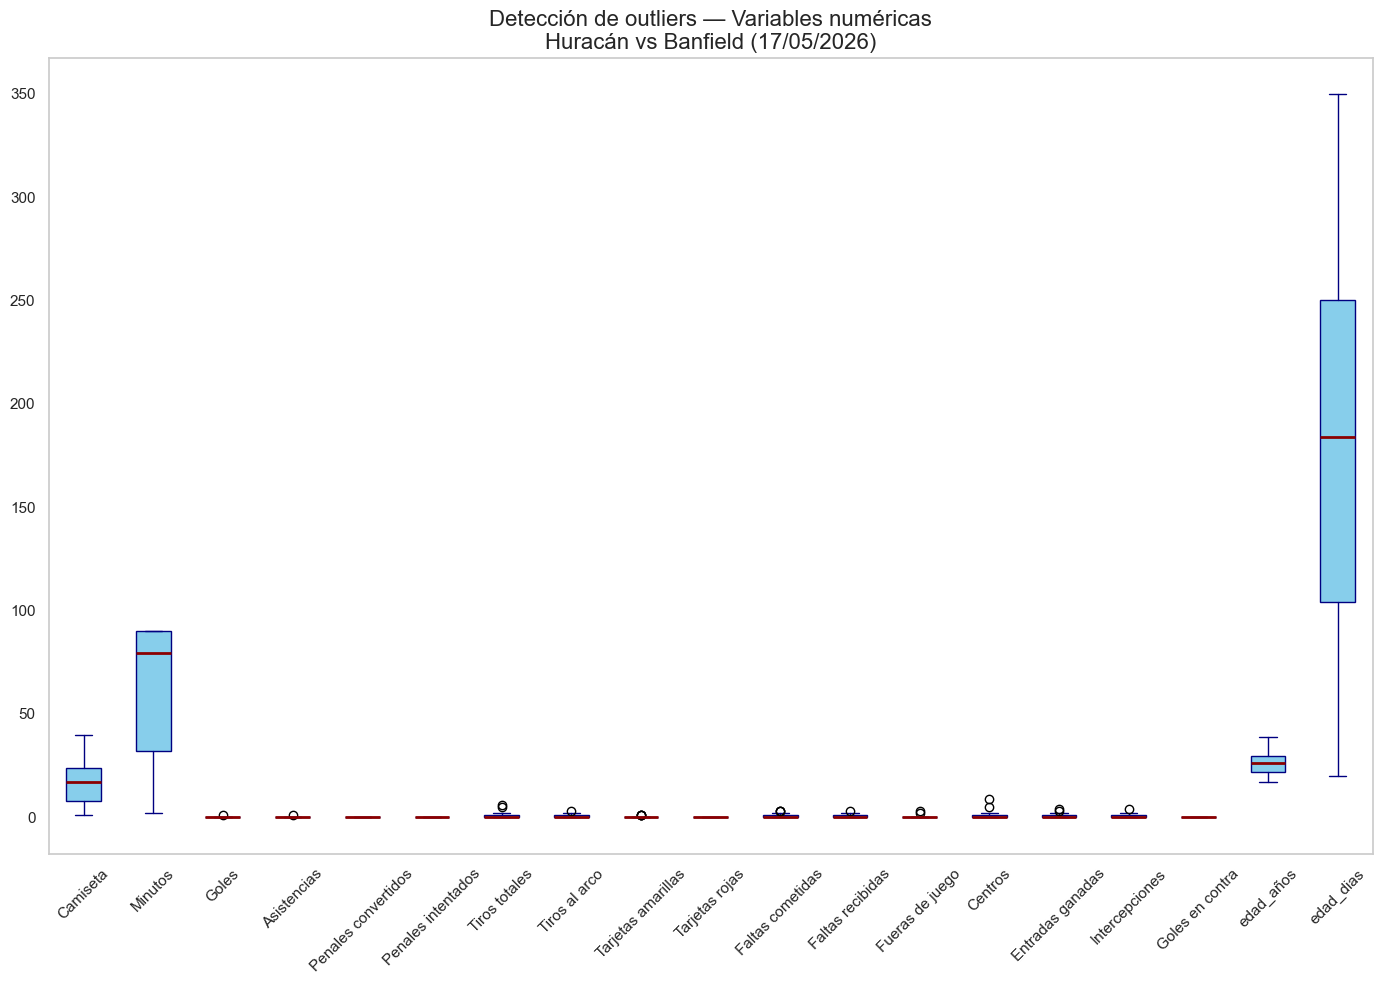

In [10]:
columnas_numericas = df_clean.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(14, 10))
df_clean[columnas_numericas].boxplot(
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='navy'),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    medianprops=dict(color='darkred', linewidth=2)
)
plt.title(f'Detección de outliers — Variables numéricas\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} ({FECHA})')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/outliers.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Filtro de jugadores activos

Para los análisis ofensivo y defensivo trabajamos solo con jugadores que tuvieron minutos en el partido.  
Los jugadores en el banco sin ingresar quedan excluidos de las visualizaciones.

In [11]:
df_activos = df_clean[df_clean['Minutos'] > 0].copy()
print(f'Jugadores con minutos jugados: {len(df_activos)} de {len(df_clean)} en el dataset')

Jugadores con minutos jugados: 32 de 32 en el dataset


### 4.5 Tiros totales por jugador

**Pregunta táctica:** ¿Quiénes generaron más situaciones de peligro ofensivo?

Los tiros totales son el indicador más directo de presencia ofensiva en el partido.  
Incluye tiros al arco y fuera del arco.

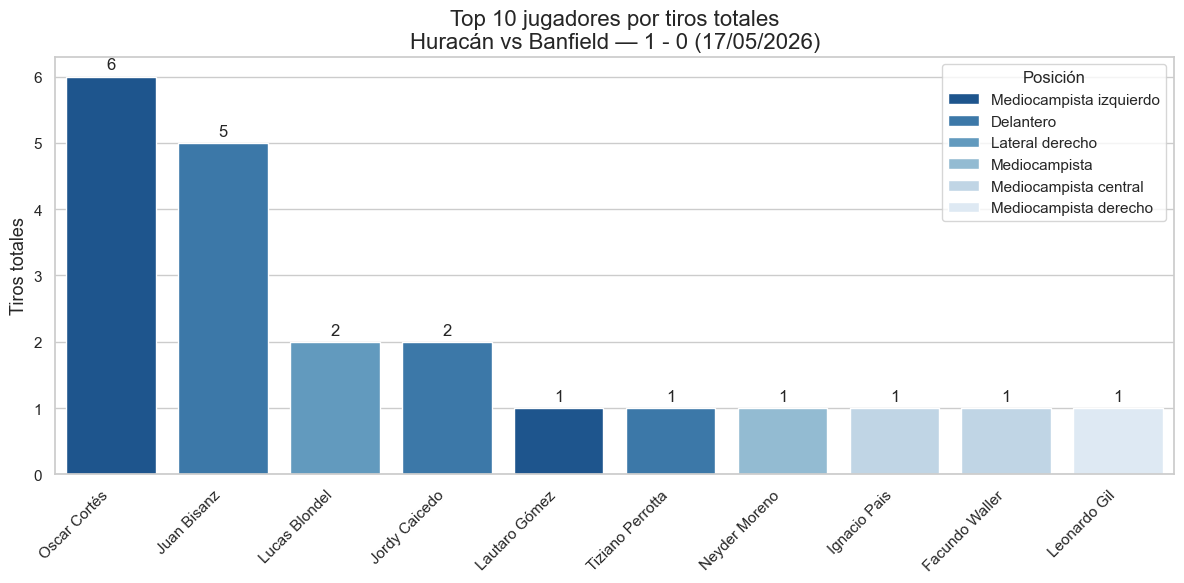

In [12]:
df_ofensivo = df_activos[['Jugador', 'Posición', 'Minutos',
                            'Tiros totales', 'Tiros al arco',
                            'Goles', 'Asistencias']].copy()
df_ofensivo = df_ofensivo.sort_values('Tiros totales', ascending=False)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_ofensivo.head(10),
    x='Jugador',
    y='Tiros totales',
    hue='Posición',
    dodge=False,
    palette='Blues_r'
)
for container in p.containers:
    p.bar_label(container, label_type='edge', padding=3)
plt.title(f'Top 10 jugadores por tiros totales\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/top_tiros.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Acciones defensivas por jugador

**Pregunta táctica:** ¿Quiénes fueron los jugadores más activos en tareas defensivas?

Combinamos entradas ganadas e intercepciones como métrica de trabajo defensivo.  
Permite identificar qué línea del equipo tuvo mayor carga defensiva en el partido.

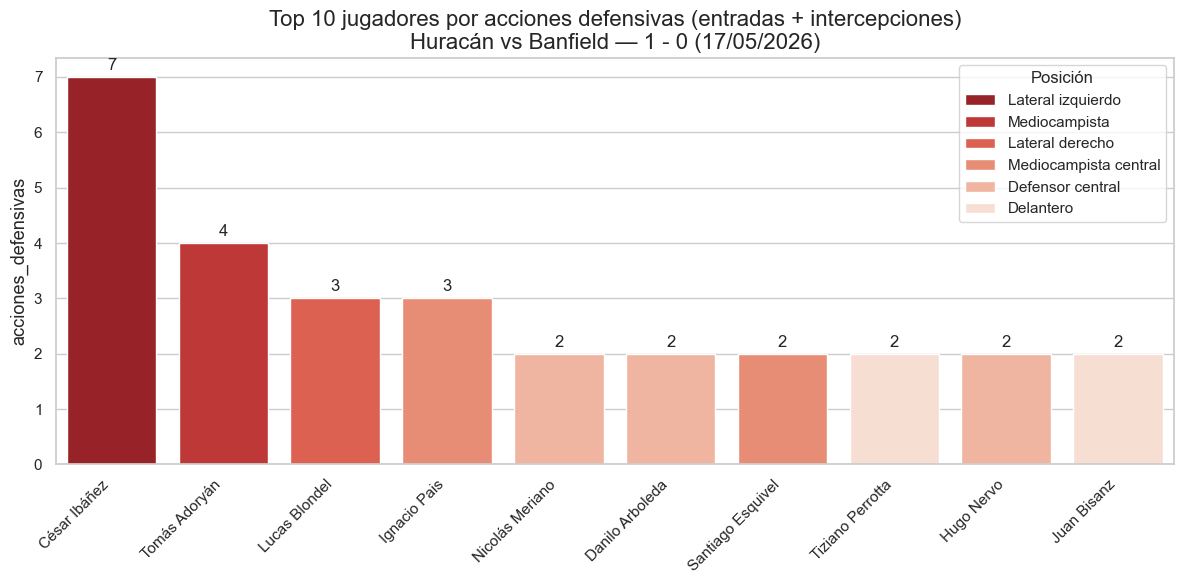

In [13]:
df_activos['acciones_defensivas'] = (
    df_activos['Entradas ganadas'] + df_activos['Intercepciones']
)

df_def = df_activos[['Jugador', 'Posición', 'Minutos',
                       'Entradas ganadas', 'Intercepciones',
                       'acciones_defensivas']].sort_values(
    'acciones_defensivas', ascending=False
)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_def.head(10),
    x='Jugador',
    y='acciones_defensivas',
    hue='Posición',
    dodge=False,
    palette='Reds_r'
)
for container in p.containers:
    p.bar_label(container, label_type='edge', padding=3)
plt.title(f'Top 10 jugadores por acciones defensivas (entradas + intercepciones)\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/acciones_defensivas.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7 Perfil individual — Máximo Palazzo

**Pregunta táctica:** ¿Cómo fue el partido de Máximo Palazzo en comparación con el promedio de su posición?

La función compara cada métrica del jugador con el promedio de los jugadores de su misma posición en el partido.

In [14]:
def perfil_jugador(df: pd.DataFrame, nombre: str) -> None:
    """
    Muestra el perfil completo de un jugador en el partido.
    Compara sus métricas con el promedio de su posición.
    """
    jugador = df[df['Jugador'].str.contains(nombre, case=False, na=False)]

    if jugador.empty:
        print(f"Jugador '{nombre}' no encontrado")
        return

    jugador = jugador.iloc[0]
    posicion = jugador['Posición']
    promedio_pos = df[df['Posición'] == posicion].select_dtypes(include='number').mean()

    metricas = ['Minutos', 'Tiros totales', 'Tiros al arco', 'Goles',
                'Asistencias', 'Entradas ganadas', 'Intercepciones',
                'Faltas cometidas', 'Faltas recibidas', 'Centros']

    metricas_presentes = [m for m in metricas if m in df.columns]

    print(f"\n{'='*55}")
    print(f"PERFIL: {jugador['Jugador']} | {posicion} | {jugador['Minutos']} min")
    print(f"Partido: {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})")
    print(f"{'='*55}")
    print(f"{'Métrica':<25} {'Valor':>8} {'Prom. posición':>15}")
    print(f"{'-'*55}")
    for m in metricas_presentes:
        if m in jugador.index and m in promedio_pos.index:
            diff = jugador[m] - promedio_pos[m]
            indicador = '▲' if diff > 0 else ('▼' if diff < 0 else '─')
            print(f"{m:<25} {jugador[m]:>8.0f} {promedio_pos[m]:>15.1f}  {indicador}")
    print(f"{'='*55}")
    print("▲ por encima del promedio | ▼ por debajo | ─ igual")

perfil_jugador(df_activos, 'Máximo Palazzo')


PERFIL: Máximo Palazzo | Defensor central | 90 min
Partido: Huracán vs Banfield — 1 - 0 (17/05/2026)
Métrica                      Valor  Prom. posición
-------------------------------------------------------
Minutos                         90            90.0  ─
Tiros totales                    1             0.2  ▲
Tiros al arco                    1             0.2  ▲
Goles                            0             0.0  ─
Asistencias                      0             0.0  ─
Entradas ganadas                 0             0.5  ▼
Intercepciones                   1             1.2  ▼
Faltas cometidas                 0             0.0  ─
Faltas recibidas                 0             0.0  ─
Centros                          0             0.0  ─
▲ por encima del promedio | ▼ por debajo | ─ igual
